In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
#transforms.ToTensor()  
raw_image =  torchvision.datasets.FashionMNIST('../data/raw', train = True, download = False, transform = None)
tensor_image = torchvision.datasets.FashionMNIST('../data/raw', train = True, download = False, transform = transforms.ToTensor())

In [2]:
random_sample_list = [1, 10 , 100, 500]
sample_image = []
sample_label = []
for sample_num in random_sample_list:
    image, label = raw_image[sample_num]
    sample_image.append(image)
    sample_label.append(label)
    

In [3]:
test_data = torchvision.datasets.FashionMNIST('../data/raw', train = False, download = False, transform = transforms.ToTensor())

In [4]:
print(sample_label)

[0, 0, 8, 3]


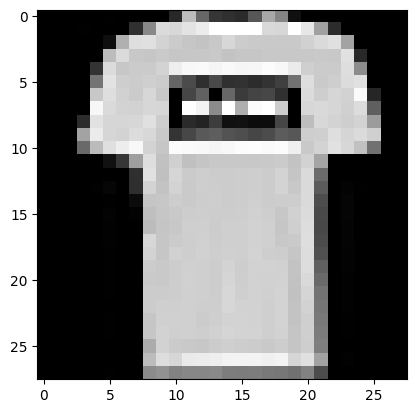

In [5]:
plt.imshow(sample_image[0], cmap = 'gray')

In [6]:
fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}



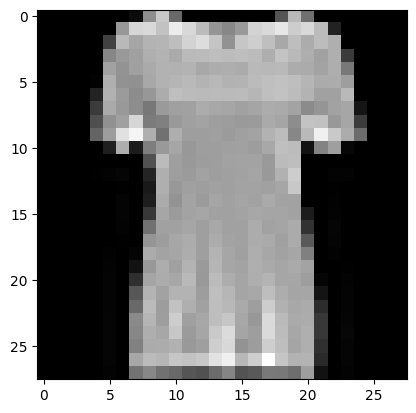

In [7]:
plt.imshow(sample_image[1], cmap = 'gray')

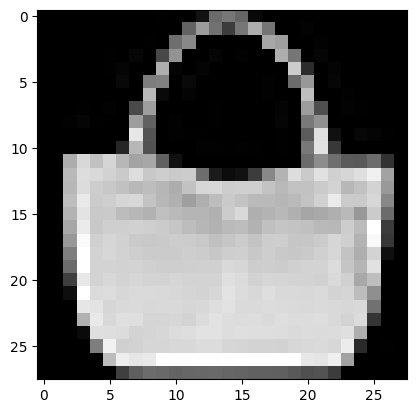

In [8]:
plt.imshow(sample_image[2], cmap = 'gray')

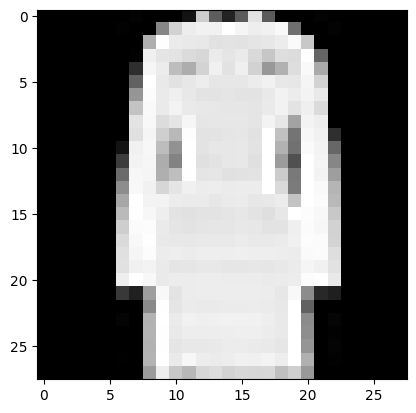

In [9]:
plt.imshow(sample_image[3], cmap = 'gray')

In [10]:
len(raw_image)

60000

In [12]:
train_loader = DataLoader(tensor_image, shuffle = True, batch_size = 64, num_workers = 0)
test_loader = DataLoader(test_data, shuffle =False, batch_size = 64, num_workers = 0)

In [13]:
import numpy as np
import torch.nn as nn


In [17]:
class CNN_model(nn.Module):
    def __init__(self): 
        super().__init__()

        self.conv_L1 = nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels= 6, kernel_size=5,  stride=1, padding=0),
        nn.ReLU(),
        nn.AvgPool2d(kernel_size= 2, stride= 2)
    )
        self.conv_L2 = nn.Sequential(
        nn.Conv2d(in_channels= 6, out_channels = 10, kernel_size=5, stride = 1, padding= 0),
        nn.ReLU(),
        nn.AvgPool2d(kernel_size=2, stride=2)
    )
        self.flatten = nn.Flatten()
        self.fc_block = nn.Sequential(
        nn.Linear(4*4*10, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10)
    )

    def forward(self, x):
        x = self.conv_L1(x)
        x = self.conv_L2(x)
        x = self.flatten(x)
        x = self.fc_block(x)
        return x
        

In [20]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN_model()
model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 1e-4)